# import libraries

In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (recall_score, accuracy_score, precision_score, \
        f1_score, accuracy_score, confusion_matrix, precision_recall_curve)
import matplotlib.pyplot as plt

# Read Dataset and Print Info

In [2]:
gym_data = pd.DataFrame({
    "visits_per_month": 
[6,5,0,4,15,12,18,4,17,6,6,0,11,18,8,0,16,12,16,14,17,13,3,19,13,15,15,4,0,16,18,15,0,11,4,0,0,5,17, 15,17,10,0,6,5,10,14,4,13,19,6,7,17,4,5,17,3,7,0,12,19,12,1,14,13,9,11,6,8,19,12,8,10,17,14,5,12,7, 2,4,14,12,9,16,11,9,3,10,4,16],
    "avg_session_min": 
[51.1,40.8,15.4,74.2,42.2,44.3,26.8,54.0,66.4,56.7,25.1,18.6,66.3,73.9,48.1,13.9,40.4,27.1,49.5,51.0 ,42.2,51.2,13.4,43.6,54.7,49.9,74.3,47.5,11.3,25.4,51.7,47.2,12.6,32.4,54.5,11.0,13.1,28.6,33.4,45.6 ,38.9,64.9,24.3,58.1,42.0,72.3,66.1,53.3,64.1,25.1,68.6,52.4,49.4,63.6,63.1,62.6,17.9,71.0,13.2,50.1 ,59.8,48.8,22.6,27.8,49.8,30.3,51.6,56.8,33.3,54.3,31.1,52.9,35.4,65.0,37.1,47.1,73.8,59.7,12.0,59.5,72.2,52.2,62.6,51.2,37.1,46.4,16.8,39.4,37.3,42.7],
    "days_since_last_visit": 
[8,10,21,1,10,11,8,1,14,3,7,41,1,6,14,20,8,7,12,14,2,14,23,12,7,4,10,5,46,4,11,4,58,11,10,26,49,4,14,5,13,5,43,13,10,7,1,5,2,13,14,11,1,12,3,7,27,3,25,9,1,5,27,11,8,4,9,0,9,5,12,10,5,1,4,2,12,10,55,10,8,14,13,8,3,11,34,12,6,8],
    "has_personal_trainer": 
    [1,1,0,1,1,0,1,1,1,1,1,0,1,0,1,0,1,1,0,1,1,1,1,1,1,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,1,1,1,1,0,1,0,1,0,1,1,1,1,1,1,0,1,0,1,1,1,1,1,1,1,0,1,0,1,0,1,1,0,1,1,0,1,1,0,0],
    "churned": 
        [0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0]
})

In [3]:
gym_data.head()

,visits_per_month,avg_session_min,days_since_last_visit,has_personal_trainer,churned
0,6,51.1,8,1,0
1,5,40.8,10,1,0
2,0,15.4,21,0,1
3,4,74.2,1,1,0
4,15,42.2,10,1,0


In [14]:
label_1_count = np.sum(gym_data['churned'] == 1)
label_0_count = np.sum(gym_data['churned'] == 0)
num_of_samples = gym_data.shape[0]

print(f"There are {label_1_count} samples of class 1 with {label_1_count/num_of_samples:.2f} freq.")
print(f"There are {label_1_count} samples of class 0 with {label_0_count/num_of_samples:.2f} freq.")

There are 14 samples of class 1 with 0.16 freq.
There are 14 samples of class 0 with 0.84 freq.


# Split Dataset

In [17]:
attrs = ['visits_per_month', 'avg_session_min',	'days_since_last_visit', 'has_personal_trainer']
label_name = 'churned'
X_train, X_test, y_train, y_test = train_test_split(gym_data[attrs], gym_data[label_name],
                                            stratify=gym_data[label_name], test_size=0.2, random_state=42)

# Create Pipelines and Train Model

In [19]:
pipline = make_pipeline(StandardScaler(), LogisticRegression())
pipline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

# Display Metrics

In [23]:
preds = pipline.predict(X_test)

metrics_dict = {
    'f1': [f1_score(y_test, preds)],
    'recall': [recall_score(y_test, preds)],
    'precision': [precision_score(y_test, preds)],
    'accuracy': [accuracy_score(y_test, preds)],
}

metrics_df = pd.DataFrame(metrics_dict)
metrics_df

,f1,recall,precision,accuracy
0,1.0,1.0,1.0,1.0


In [25]:
y_test == preds

63    True
37    True
71    True
79    True
25    True
11    True
87    True
28    True
84    True
3     True
64    True
27    True
24    True
17    True
46    True
78    True
72    True
1     True
Name: churned, dtype: bool

In [35]:
cm = confusion_matrix(y_test, preds)
cm

array([[15,  0],
       [ 0,  3]])

In [40]:
cm_dict = {'TN' : [cm[0, 0]], 'FP': [cm[0, 1]], 'FN': [cm[1, 0]], 'TP': [cm[1, 1]]}
cm_df = pd.DataFrame(cm_dict)
cm_df

,TN,FP,FN,TP
0,15,0,0,3


# Reason

In [39]:
# Data is imbalanced
dummy_preds = np.zeros_like(y_test)
accuracy_score(y_test, dummy_preds)

0.8333333333333334

- ب: خروجی مدل ایده‌آل است ولی برای پاسخ به سوال فرض می‌کنیم مدل ایده‌آل رفتار نکرده است. اگر سیاست این باشد جلوی خروج ورزشکار را بگیریم و از طرفی پیش بینی اشتباه کسی که باشگاه را ترک می‌کند کم باشد بایستی تمرکز روی افزایش ریکال باشد. اگر به اشتباه کسی را در حال ترک پیش بینی کنیم تنها هزینه ما اعتای کوپن و تخفیف به ان فرد وفادار خواهد بود ولی عدم شناسایی کسی که باشگاه را تکر میکند در مقیاس بزرگتری هزینه روی دست باشگاه میگذارد. همچنین دیدیم چنانچه فرض کنیم هیچ فردی در حال ترک نیست به دقت 83 درصد خواهیم رسید.

- فالس پاسیتیو. اگر همه افراد را به اشتباه در حال ترک بداند هزینه بیجا و زیادی خرج خواهد شد.

In [43]:
# Recall will increase
predictions = pipline.predict_proba(X_test)[:, 1]
preds = predictions > 0.3

metrics_dict = {
    'f1': [f1_score(y_test, preds)],
    'recall': [recall_score(y_test, preds)],
    'precision': [precision_score(y_test, preds)],
    'accuracy': [accuracy_score(y_test, preds)],
}

metrics_df = pd.DataFrame(metrics_dict)
metrics_df

,f1,recall,precision,accuracy
0,1.0,1.0,1.0,1.0


In [46]:
# Recall will increase
predictions = pipline.predict_proba(X_test)[:, 1]
preds = predictions > 0.01

metrics_dict = {
    'f1': [f1_score(y_test, preds)],
    'recall': [recall_score(y_test, preds)],
    'precision': [precision_score(y_test, preds)],
    'accuracy': [accuracy_score(y_test, preds)],
}

metrics_df = pd.DataFrame(metrics_dict)
metrics_df

,f1,recall,precision,accuracy
0,0.375,1.0,0.230769,0.444444


In [48]:
prec, recall, thresholds = precision_recall_curve(y_test, predictions)

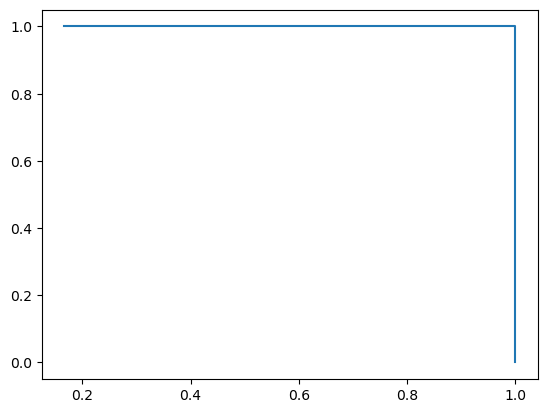

In [50]:
plt.plot(prec, recall)
plt.show()